# Semi-Supervised MNIST Classification — Full Pipeline

**Flow:**
- Stage 1: SimCLR (Modified ResNet-18) → Label Propagation (+ confidence filter)
- Stage 2: cVAE pretraining (β annealing)
- Stage 3: GAN main loop (frozen SimCLR + EfficientNet features projected → concat, trainable ResNet + SpectralNorm)
- Inference: SWA-D + TTA (5 aug views → softmax avg)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset
from torch.optim.swa_utils import AveragedModel, SWALR
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.models as tvm
import numpy as np
import random
import math
import copy
from dataclasses import dataclass
from typing import Optional, Tuple, List
import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
@dataclass
class Config:
    # Data
    n_labeled:       int   = 500
    n_unlabeled:     int   = 3000
    n_classes:       int   = 10
    img_size:        int   = 32   # resize MNIST to 32×32 (3ch)

    # Stage 1: SimCLR
    simclr_epochs:   int   = 200
    simclr_lr:       float = 3e-4
    simclr_batch:    int   = 256
    simclr_feat:     int   = 512
    simclr_proj:     int   = 128
    simclr_temp:     float = 0.5

    # Stage 1b: Label Propagation
    lp_k:            int   = 15
    lp_alpha:        float = 0.99
    lp_iters:        int   = 60
    lp_conf:         float = 0.85  # min max-prob to keep pseudo-label

    # Stage 2: cVAE
    cvae_epochs:     int   = 100
    cvae_lr:         float = 1e-3
    cvae_batch:      int   = 128
    latent_dim:      int   = 64
    beta_start:      float = 4.0   # annealed → beta_end
    beta_end:        float = 0.5
    lambda_percep:   float = 0.1   # SimCLR perceptual weight

    # Stage 3: GAN
    gan_epochs:      int   = 300
    gan_lr_d:        float = 2e-4
    gan_lr_g:        float = 2e-4
    gan_lr_cls:      float = 1e-4
    gan_batch:       int   = 128

    # Loss weights (raw; schedule overrides below)
    lam_cls:         float = 1.0
    lam_gen:         float = 0.5
    lam_sc:          float = 0.3
    lam_pseudo:      float = 0.5
    lam_fm:          float = 1.0

    # Loss warmup epochs
    warmup_gen:      int   = 20
    warmup_sc:       int   = 30

    # Pseudo-label refresh cadence
    pseudo_refresh:  int   = 20

    # EMA (Generator) / SWA (Discriminator)
    ema_decay:       float = 0.999
    swa_start:       float = 0.75  # fraction of gan_epochs

    # ADA
    ada_target:      float = 0.6
    ada_interval:    int   = 4

    # Feature projection dimensions (compress before concat)
    simclr_comp:     int   = 128
    eff_comp:        int   = 128
    train_feat:      int   = 512   # trainable ResNet-18 output
    disc_hidden:     int   = 512   # discriminator shared layer

    device: str = DEVICE

cfg = Config()

In [3]:
class MNISTSemiDataset(Dataset):
    """Wraps tensors; label=-1 means unlabeled."""
    def __init__(self, images: torch.Tensor, labels: torch.Tensor):
        self.images = images   # (N, 3, 32, 32) float [0,1]
        self.labels = labels   # (N,) int, -1 = unlabeled

    def __len__(self): return len(self.images)
    def __getitem__(self, i):
        return self.images[i], self.labels[i]

def load_mnist(cfg: Config):
    """Download MNIST, resize to 3×32×32, split into labeled/unlabeled/test."""
    tf = T.Compose([
        T.Resize(cfg.img_size),
        T.ToTensor(),
        T.Lambda(lambda x: x.repeat(3, 1, 1)),  # 1ch → 3ch
    ])
    full_train = torchvision.datasets.MNIST(root="./data", train=True,
                                            download=True, transform=tf)
    test_ds    = torchvision.datasets.MNIST(root="./data", train=False,
                                            download=True, transform=tf)

    # Balanced labeling: n_labeled // n_classes per class
    per_class = cfg.n_labeled // cfg.n_classes
    labeled_idx, unlabeled_idx = [], []
    counts = {c: 0 for c in range(cfg.n_classes)}
    perm = torch.randperm(len(full_train)).tolist()
    for i in perm:
        _, lbl = full_train[i]
        if counts[lbl] < per_class:
            labeled_idx.append(i); counts[lbl] += 1
        elif len(unlabeled_idx) < cfg.n_unlabeled:
            unlabeled_idx.append(i)
        if len(labeled_idx) == cfg.n_labeled and len(unlabeled_idx) == cfg.n_unlabeled:
            break

    def collect(ds, idx, mask_label=False):
        imgs, lbls = [], []
        for i in idx:
            im, lb = ds[i]
            imgs.append(im)
            lbls.append(-1 if mask_label else lb)
        return torch.stack(imgs), torch.tensor(lbls)

    lx, ly = collect(full_train, labeled_idx)
    ux, uy = collect(full_train, unlabeled_idx, mask_label=True)

    test_imgs  = torch.stack([test_ds[i][0] for i in range(len(test_ds))])
    test_lbls  = torch.tensor([test_ds[i][1] for i in range(len(test_ds))])

    print(f"Labeled: {len(lx)}, Unlabeled: {len(ux)}, Test: {len(test_imgs)}")
    return lx, ly, ux, test_imgs, test_lbls

lx, ly, ux, test_imgs, test_lbls = load_mnist(cfg)

Labeled: 500, Unlabeled: 3000, Test: 10000


In [4]:
#
# Philosophy:
#   We never pile every augmentation onto one image.
#   Instead we generate named *views* and pick which view
#   to use per training objective:
#
#   View       | Transform                         | Used for
#   -----------|-----------------------------------|-----------------------------
#   clean      | none                              | pseudo-label scoring, LP
#   light      | crop + hflip                      | early classifier warmup
#   diff       | DiffAugment (color+transl+cutout) | SimCLR pairs, SupCon, D real/fake
#   mixup_b    | Mixup  (batch-level)              | classifier mid-stage
#   cutmix_b   | CutMix (batch-level)              | classifier mid-stage
#   diff_mix   | diff → mixup/cutmix               | classifier late-stage
#
# ADA controls the probability that 'diff' is actually applied to D's input
# (real and fake are augmented identically to keep the loss unbiased).

# ---------- Differentiable Augment ----------
def rand_brightness(x: torch.Tensor) -> torch.Tensor:
    factor = torch.empty(x.size(0), 1, 1, 1, device=x.device).uniform_(0.5, 1.5)
    return (x * factor).clamp(0, 1)

def rand_saturation(x: torch.Tensor) -> torch.Tensor:
    gray = x.mean(dim=1, keepdim=True)
    factor = torch.empty(x.size(0), 1, 1, 1, device=x.device).uniform_(0.5, 1.5)
    return torch.lerp(gray, x, factor).clamp(0, 1)

def rand_contrast(x: torch.Tensor) -> torch.Tensor:
    mean = x.mean(dim=(1,2,3), keepdim=True)
    factor = torch.empty(x.size(0), 1, 1, 1, device=x.device).uniform_(0.5, 1.5)
    return torch.lerp(mean, x, factor).clamp(0, 1)

def rand_translation(x: torch.Tensor, ratio: float = 0.125) -> torch.Tensor:
    B, C, H, W = x.shape
    shift_h = int(H * ratio)
    shift_w = int(W * ratio)
    tx = torch.randint(-shift_w, shift_w + 1, (B,))
    ty = torch.randint(-shift_h, shift_h + 1, (B,))
    # Use grid_sample for differentiability
    theta = torch.zeros(B, 2, 3, device=x.device)
    theta[:, 0, 0] = 1; theta[:, 1, 1] = 1
    theta[:, 0, 2] = tx.float() / W * 2
    theta[:, 1, 2] = ty.float() / H * 2
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    return F.grid_sample(x, grid, align_corners=False, padding_mode="reflection")

def rand_cutout(x: torch.Tensor, ratio: float = 0.5) -> torch.Tensor:
    B, C, H, W = x.shape
    cut_h = int(H * ratio); cut_w = int(W * ratio)
    out = x.clone()
    for i in range(B):
        top  = random.randint(0, H - cut_h)
        left = random.randint(0, W - cut_w)
        out[i, :, top:top+cut_h, left:left+cut_w] = 0
    return out

DIFF_FUNCS = [rand_brightness, rand_saturation, rand_contrast,
              rand_translation, rand_cutout]

def diff_augment(x: torch.Tensor, policy: str = "color,translation,cutout") -> torch.Tensor:
    for p in policy.split(","):
        p = p.strip()
        if p == "color":
            for fn in [rand_brightness, rand_saturation, rand_contrast]:
                x = fn(x)
        elif p == "translation":
            x = rand_translation(x)
        elif p == "cutout":
            x = rand_cutout(x)
    return x.clamp(0, 1)

# ---------- Mixup / CutMix (batch-level) ----------
def mixup(x: torch.Tensor, y: torch.Tensor, alpha: float = 0.4
          ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, float]:
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    return mixed_x, y, y[idx], lam

def cutmix(x: torch.Tensor, y: torch.Tensor, alpha: float = 1.0
           ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, float]:
    lam = np.random.beta(alpha, alpha)
    B, C, H, W = x.shape
    cut_ratio = math.sqrt(1 - lam)
    cut_h = int(H * cut_ratio); cut_w = int(W * cut_ratio)
    cx = random.randint(0, W); cy = random.randint(0, H)
    x1 = max(0, cx - cut_w // 2); x2 = min(W, cx + cut_w // 2)
    y1 = max(0, cy - cut_h // 2); y2 = min(H, cy + cut_h // 2)
    lam = 1 - (x2 - x1) * (y2 - y1) / (W * H)
    idx = torch.randperm(B, device=x.device)
    mixed = x.clone()
    mixed[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    return mixed, y, y[idx], lam

def mix_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ---------- Light augment (CPU, for early warmup) ----------
_light_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
])
def light_aug(x: torch.Tensor) -> torch.Tensor:
    return torch.stack([_light_tf(xi) for xi in x])

# ---------- ADA probability tracker ----------
class ADAController:
    def __init__(self, target: float = 0.6, interval: int = 4, speed: float = 1e-3):
        self.p = 0.0
        self.target = target
        self.interval = interval
        self.speed = speed
        self._step = 0
        self._signs: List[float] = []

    def update(self, real_logits: torch.Tensor):
        """Call once per D step with real logits (before sigmoid)."""
        signs = (real_logits > 0).float().mean().item()
        self._signs.append(signs)
        self._step += 1
        if self._step % self.interval == 0:
            rt = np.mean(self._signs[-self.interval:])
            adjust = np.sign(rt - self.target) * self.speed * self.interval
            self.p = float(np.clip(self.p + adjust, 0.0, 1.0))

    def apply(self, x: torch.Tensor) -> torch.Tensor:
        """Apply DiffAugment with probability self.p."""
        if random.random() < self.p:
            return diff_augment(x)
        return x

# ---------- View generator ----------
class ViewGenerator:
    """Produces named views for each batch."""
    def __init__(self, ada: ADAController):
        self.ada = ada

    def clean(self, x): return x

    def light(self, x): return light_aug(x)

    def diff(self, x): return diff_augment(x)

    def diff_for_disc(self, x):
        """ADA-controlled diff augment for discriminator."""
        return self.ada.apply(x)

    def simclr_pair(self, x):
        """Two independent DiffAugment views for contrastive loss."""
        return diff_augment(x), diff_augment(x)

    def diff_supcon(self, x):
        """Two views for SupCon."""
        return diff_augment(x), diff_augment(x)

ada = ADAController(target=cfg.ada_target, interval=cfg.ada_interval)
views = ViewGenerator(ada)

# ---------- Augmentation curriculum helper ----------
def get_cls_view(x: torch.Tensor, y: torch.Tensor, epoch: int, cfg: Config):
    """
    Returns (x_aug, y_a, y_b, lam) for classifier CE loss.
    Curriculum:
      epoch < warmup_gen        → clean only
      warmup_gen ≤ epoch < 60  → light aug
      60 ≤ epoch < 120         → light + 50% Mixup
      epoch ≥ 120              → light + 50% Mixup or 50% CutMix
    """
    if epoch < cfg.warmup_gen:
        return x, y, y, 1.0
    x = light_aug(x.cpu()).to(x.device)
    if epoch < 60:
        return x, y, y, 1.0
    if epoch < 120:
        if random.random() < 0.5:
            x, ya, yb, lam = mixup(x, y)
            return x, ya, yb, lam
        return x, y, y, 1.0
    # epoch >= 120: Mixup or CutMix
    if random.random() < 0.5:
        fn = mixup if random.random() < 0.5 else cutmix
        x, ya, yb, lam = fn(x, y)
        return x, ya, yb, lam
    return x, y, y, 1.0

In [5]:

# ---- Spectral-normed helpers ----
def sn_linear(in_f, out_f, **kw):   return spectral_norm(nn.Linear(in_f, out_f, **kw))
def sn_conv(in_c, out_c, k, **kw): return spectral_norm(nn.Conv2d(in_c, out_c, k, **kw))

# ---- Modified ResNet-18 (32×32 friendly) ----
class ResNet18Small(nn.Module):
    """ResNet-18 adapted for 32×32: no maxpool, 3×3 first conv."""
    def __init__(self, feat_dim: int = 512, use_spectral: bool = False):
        super().__init__()
        base = tvm.resnet18(weights=None)
        # Adapt for small images
        base.conv1  = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
        base.maxpool = nn.Identity()
        self.encoder = nn.Sequential(
            base.conv1, base.bn1, base.relu,
            base.layer1, base.layer2, base.layer3, base.layer4,
            base.avgpool,
        )
        self.feat_dim = feat_dim
        # Optional: wrap conv layers with spectral norm
        if use_spectral:
            self._apply_spectral_norm()

    def _apply_spectral_norm(self):
        for m in self.encoder.modules():
            if isinstance(m, nn.Conv2d):
                spectral_norm(m)

    def forward(self, x):
        return self.encoder(x).flatten(1)  # (B, 512)

# ---- SimCLR model ----
class SimCLR(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.backbone = ResNet18Small(cfg.simclr_feat)
        self.projector = nn.Sequential(
            nn.Linear(cfg.simclr_feat, cfg.simclr_feat),
            nn.ReLU(),
            nn.Linear(cfg.simclr_feat, cfg.simclr_proj),
        )

    def encode(self, x):
        return self.backbone(x)

    def forward(self, x):
        h = self.backbone(x)
        z = self.projector(h)
        return F.normalize(z, dim=-1)

# ---- EfficientNet-B0 feature extractor ----
class EfficientNetB0Features(nn.Module):
    def __init__(self):
        super().__init__()
        eff = tvm.efficientnet_b0(weights=None)
        # Remove the classifier; keep features (output: 1280-d)
        self.features = eff.features
        self.pool = eff.avgpool

    def forward(self, x):
        return self.pool(self.features(x)).flatten(1)  # (B, 1280)

# ---- cVAE Encoder ----
class CVAEEncoder(nn.Module):
    def __init__(self, img_ch: int = 3, img_size: int = 32,
                 n_classes: int = 10, latent_dim: int = 64):
        super().__init__()
        self.embed = nn.Embedding(n_classes, 16)
        # Conditional: concat class embedding as extra channels (tiled)
        self.net = nn.Sequential(
            nn.Conv2d(img_ch + 16, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
            nn.Flatten(),
        )
        self.fc_mu     = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x, y):
        e = self.embed(y)[:, :, None, None].expand(-1, -1, x.size(2), x.size(3))
        h = self.net(torch.cat([x, e], 1))
        return self.fc_mu(h), self.fc_logvar(h)

# ---- cVAE / GAN Generator ----
class Generator(nn.Module):
    def __init__(self, latent_dim: int = 64, n_classes: int = 10,
                 img_ch: int = 3, img_size: int = 32):
        super().__init__()
        self.latent_dim = latent_dim
        self.embed = nn.Embedding(n_classes, 64)
        self.fc = nn.Linear(latent_dim + 64, 256 * 4 * 4)
        self.net = nn.Sequential(
            nn.BatchNorm2d(256),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64,  4, 2, 1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.ConvTranspose2d(64,  32,  4, 2, 1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, img_ch, 3, 1, 1), nn.Tanh(),
        )
        self.img_size = img_size

    def forward(self, z, y):
        e = self.embed(y)
        h = F.relu(self.fc(torch.cat([z, e], 1)))
        h = h.view(-1, 256, 4, 4)
        out = self.net(h)
        if out.size(-1) != self.img_size:
            out = F.interpolate(out, self.img_size, mode="bilinear", align_corners=False)
        return (out + 1) / 2  # Tanh → [0,1]

# ---- Discriminator with projection (11-class + fake) ----
class Discriminator(nn.Module):
    """
    Input: image → three feature streams:
      1. Frozen SimCLR backbone   (simclr_feat=512) → compress → 128
      2. Frozen EfficientNet-B0  (eff_feat=1280)   → compress → 128
      3. Trainable ResNet-18 + SN (train_feat=512)
    Concat → shared MLP → 11-way output
    + Projection discriminator: inner-product with class embedding
    """
    def __init__(self, cfg: Config,
                 simclr_backbone: ResNet18Small,
                 eff_backbone: EfficientNetB0Features):
        super().__init__()
        # Frozen feature extractors
        self.simclr_backbone = simclr_backbone
        self.eff_backbone    = eff_backbone
        for p in self.simclr_backbone.parameters(): p.requires_grad_(False)
        for p in self.eff_backbone.parameters():    p.requires_grad_(False)

        # Compression projectors (trainable)
        self.simclr_comp = nn.Sequential(
            sn_linear(cfg.simclr_feat, cfg.simclr_comp), nn.LeakyReLU(0.2))
        self.eff_comp    = nn.Sequential(
            sn_linear(1280,            cfg.eff_comp),    nn.LeakyReLU(0.2))

        # Trainable backbone (SpectralNorm applied internally)
        self.train_backbone = ResNet18Small(cfg.train_feat, use_spectral=True)

        total = cfg.simclr_comp + cfg.eff_comp + cfg.train_feat  # 128+128+512=768
        self.shared = nn.Sequential(
            sn_linear(total, cfg.disc_hidden), nn.LeakyReLU(0.2),
            sn_linear(cfg.disc_hidden, cfg.simclr_proj),
        )
        # 11-way head: 0-9 real classes + fake (class 10)
        self.cls_head = sn_linear(cfg.simclr_proj, cfg.n_classes + 1)
        # Projection discriminator embedding (for real classes 0-9 only)
        self.embed = nn.Embedding(cfg.n_classes, cfg.simclr_proj)

    def features(self, x):
        with torch.no_grad():
            f_sim = self.simclr_backbone(x)
            f_eff = self.eff_backbone(x)
        f_sim = self.simclr_comp(f_sim)
        f_eff = self.eff_comp(f_eff)
        f_tr  = self.train_backbone(x)
        return self.shared(torch.cat([f_sim, f_eff, f_tr], 1))  # (B, proj_dim)

    def forward(self, x, y: Optional[torch.Tensor] = None):
        h = self.features(x)
        logits = self.cls_head(h)          # (B, 11)
        if y is not None:
            # Projection discriminator bonus for real images
            proj = (h * self.embed(y)).sum(1, keepdim=True)
            logits[:, :self.embed.num_embeddings] += proj
        return logits  # (B, 11)

In [6]:

class NTXentLoss(nn.Module):
    def __init__(self, temperature: float = 0.5):
        super().__init__()
        self.T = temperature

    def forward(self, z1: torch.Tensor, z2: torch.Tensor) -> torch.Tensor:
        N = z1.size(0)
        z  = torch.cat([z1, z2], 0)         # (2N, D)
        sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=-1) / self.T
        # Mask self-similarities
        mask = torch.eye(2*N, device=z.device).bool()
        sim.masked_fill_(mask, -1e9)
        targets = torch.arange(N, device=z.device)
        targets = torch.cat([targets + N, targets])
        return F.cross_entropy(sim, targets)

class SupConLoss(nn.Module):
    """Supervised Contrastive Loss (Khosla et al. 2020)."""
    def __init__(self, temperature: float = 0.07):
        super().__init__()
        self.T = temperature

    def forward(self, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        # features: (B, 2, D) — two views per sample
        B = features.size(0)
        f = F.normalize(features.view(2*B, -1), dim=-1)
        sim = torch.matmul(f, f.T) / self.T
        mask = torch.eye(2*B, device=f.device).bool()
        sim.masked_fill_(mask, -1e9)

        # Positive mask: same class (including the other view of same sample)
        lbl = labels.repeat(2)  # (2B,)
        pos_mask = (lbl.unsqueeze(0) == lbl.unsqueeze(1)) & ~mask
        pos_mask = pos_mask.float()

        exp_sim  = torch.exp(sim)
        log_prob = sim - torch.log(exp_sim.sum(1, keepdim=True) + 1e-8)
        loss = -(pos_mask * log_prob).sum(1) / (pos_mask.sum(1).clamp(min=1))
        return loss.mean()

class HingeLoss:
    """Non-saturating hinge adversarial loss."""
    @staticmethod
    def d_real(logits): return F.relu(1. - logits).mean()
    @staticmethod
    def d_fake(logits): return F.relu(1. + logits).mean()
    @staticmethod
    def g(logits):      return -logits.mean()

def feature_matching_loss(real_feat: torch.Tensor, fake_feat: torch.Tensor) -> torch.Tensor:
    return F.l1_loss(fake_feat, real_feat.detach())

def soft_kl_loss(pred_logits: torch.Tensor, soft_targets: torch.Tensor) -> torch.Tensor:
    """KL divergence from soft pseudo-labels."""
    log_p = F.log_softmax(pred_logits, dim=-1)
    q     = soft_targets.clamp(1e-6, 1.0)
    return F.kl_div(log_p, q, reduction="batchmean")

def vae_loss(recon, x, mu, logvar, beta, perc_fn=None, perc_w=0.0):
    recon_loss = F.l1_loss(recon, x)
    kl_loss    = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean()
    loss = recon_loss + beta * kl_loss
    if perc_fn is not None and perc_w > 0:
        loss += perc_w * perc_fn(recon, x)
    return loss, recon_loss, kl_loss

In [8]:

def train_simclr(cfg: Config, lx, ux):
    """Train SimCLR on all images (labeled + unlabeled) with DiffAugment pairs."""
    all_imgs = torch.cat([lx, ux], 0)
    ds = TensorDataset(all_imgs)
    loader = DataLoader(ds, batch_size=cfg.simclr_batch, shuffle=True,
                        num_workers=0, pin_memory=True, drop_last=True)

    model = SimCLR(cfg).to(cfg.device)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg.simclr_lr, weight_decay=1e-6)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.simclr_epochs)
    crit  = NTXentLoss(cfg.simclr_temp)

    import os
    save_path = "simclr_best.pth"
    if os.path.exists(save_path):
        print(f"Loading SimCLR from {save_path}")
        model.load_state_dict(torch.load(save_path, map_location=cfg.device, mmap=False))
        return model

    best_loss = float("inf")
    for epoch in range(cfg.simclr_epochs):
        model.train(); total = 0.0
        for (x,) in loader:
            x = x.to(cfg.device)
            v1 = diff_augment(x)
            v2 = diff_augment(x)
            z1 = model(v1); z2 = model(v2)
            loss = crit(z1, z2)
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
        sched.step()
        avg_loss = total / len(loader)
        if (epoch+1) % 20 == 0:
            print(f"[SimCLR] ep {epoch+1}/{cfg.simclr_epochs}  loss={avg_loss:.4f}")
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), save_path)

    model.load_state_dict(torch.load(save_path, map_location=cfg.device, mmap=False))
    return model

print("=== Stage 1: SimCLR ===")
simclr_model = train_simclr(cfg, lx, ux)

=== Stage 1: SimCLR ===
[SimCLR] ep 20/200  loss=4.7698
[SimCLR] ep 40/200  loss=4.6463
[SimCLR] ep 60/200  loss=4.5868
[SimCLR] ep 80/200  loss=4.5555
[SimCLR] ep 100/200  loss=4.5289
[SimCLR] ep 120/200  loss=4.5167
[SimCLR] ep 140/200  loss=4.4881
[SimCLR] ep 160/200  loss=4.4796
[SimCLR] ep 180/200  loss=4.4762
[SimCLR] ep 200/200  loss=4.4708


In [9]:

def label_propagation(cfg: Config, simclr_model, lx, ly, ux):
    """
    Zhou et al. LP on cosine k-NN graph.
    Returns soft labels for ALL images (labeled + unlabeled).
    Post-filters by confidence threshold.
    """
    from scipy.sparse import csr_matrix
    from scipy.sparse.linalg import LinearOperator

    all_imgs = torch.cat([lx, ux], 0).to(cfg.device)
    N_l = len(lx); N = len(all_imgs)

    simclr_model.eval()
    with torch.no_grad():
        feats = []
        for i in range(0, N, 256):
            feats.append(simclr_model.encode(all_imgs[i:i+256]))
        feats = torch.cat(feats, 0).cpu().numpy()

    # Normalize for cosine similarity
    feats = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)

    # Build k-NN affinity matrix
    print(f"  Building {cfg.lp_k}-NN cosine graph …")
    sim = feats @ feats.T                          # (N, N)
    np.fill_diagonal(sim, -1)
    knn_idx = np.argsort(-sim, axis=1)[:, :cfg.lp_k]
    knn_val  = sim[np.arange(N)[:, None], knn_idx]
    knn_val  = np.exp(knn_val)                     # RBF-like

    rows = np.repeat(np.arange(N), cfg.lp_k)
    cols = knn_idx.ravel(); vals = knn_val.ravel()
    W = csr_matrix((vals, (rows, cols)), shape=(N, N))
    W = (W + W.T) / 2
    d = np.asarray(W.sum(1)).ravel() ** -0.5
    # D^{-1/2} W D^{-1/2}
    D = csr_matrix((d, (np.arange(N), np.arange(N))), shape=(N, N))
    S = D @ W @ D

    # Initial label matrix
    Y = np.zeros((N, cfg.n_classes), dtype=np.float32)
    for i, lbl in enumerate(ly.numpy()):
        Y[i, lbl] = 1.0

    # Iterate: F = α S F + (1-α) Y
    F = Y.copy()
    S_dense = S.toarray().astype(np.float32)
    for it in range(cfg.lp_iters):
        F = cfg.lp_alpha * (S_dense @ F) + (1 - cfg.lp_alpha) * Y
    F = F / (F.sum(1, keepdims=True) + 1e-8)

    # Confidence filter: keep only samples where max prob ≥ threshold
    conf = F.max(axis=1)                              # (N,)
    pseudo_labels_hard = F.argmax(axis=1)

    # Soft labels (used for KL loss in Stage 3)
    soft_labels = torch.tensor(F, dtype=torch.float32)
    # Hard confident pseudo-labels (for Dataset1 construction)
    confident_mask = conf >= cfg.lp_conf
    print(f"  LP done — confident: {confident_mask.sum()}/{N} "
          f"(thresh={cfg.lp_conf})")

    return soft_labels, confident_mask, pseudo_labels_hard

print("\n=== Stage 1b: Label Propagation ===")
soft_labels, lp_mask, lp_hard = label_propagation(cfg, simclr_model, lx, ly, ux)


=== Stage 1b: Label Propagation ===
  Building 15-NN cosine graph …
  LP done — confident: 51/3500 (thresh=0.85)


In [10]:

def train_cvae(cfg: Config, simclr_model, lx, ly):
    """
    Train cVAE on labeled data only.
    β is linearly annealed β_start → β_end.
    Perceptual loss = L1 distance in SimCLR feature space.
    """
    ds = TensorDataset(lx, ly)
    loader = DataLoader(ds, batch_size=cfg.cvae_batch, shuffle=True, drop_last=True)

    enc = CVAEEncoder(3, cfg.img_size, cfg.n_classes, cfg.latent_dim).to(cfg.device)
    gen = Generator(cfg.latent_dim, cfg.n_classes, 3, cfg.img_size).to(cfg.device)
    opt = torch.optim.Adam(list(enc.parameters()) + list(gen.parameters()),
                           lr=cfg.cvae_lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, cfg.cvae_epochs)
    simclr_model.eval()

    def perceptual(recon, real):
        with torch.no_grad():
            f_real  = simclr_model.encode(real)
            f_recon = simclr_model.encode(recon)
        return F.l1_loss(f_recon, f_real)

    import os
    save_path_enc = "cvae_enc_best.pth"
    save_path_gen = "cvae_gen_best.pth"
    if os.path.exists(save_path_enc) and os.path.exists(save_path_gen):
        print(f"Loading cVAE from {save_path_enc} and {save_path_gen}")
        enc.load_state_dict(torch.load(save_path_enc, map_location=cfg.device, mmap=False))
        gen.load_state_dict(torch.load(save_path_gen, map_location=cfg.device, mmap=False))
        return enc, gen

    best_loss = float("inf")
    for epoch in range(cfg.cvae_epochs):
        beta = cfg.beta_start + (cfg.beta_end - cfg.beta_start) * epoch / cfg.cvae_epochs
        enc.train(); gen.train(); total = 0.0
        for x, y in loader:
            x, y = x.to(cfg.device), y.to(cfg.device)
            mu, logvar = enc(x, y)
            z = mu + torch.randn_like(mu) * (0.5 * logvar).exp()
            recon = gen(z, y)
            loss, rl, kl = vae_loss(recon, x, mu, logvar, beta,
                                    perc_fn=perceptual, perc_w=cfg.lambda_percep)
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
        sched.step()
        avg_loss = total / len(loader)
        if (epoch+1) % 20 == 0:
            print(f"[cVAE] ep {epoch+1}/{cfg.cvae_epochs}  "
                  f"total={avg_loss:.4f}  β={beta:.3f}")
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(enc.state_dict(), save_path_enc)
            torch.save(gen.state_dict(), save_path_gen)

    enc.load_state_dict(torch.load(save_path_enc, map_location=cfg.device, mmap=False))
    gen.load_state_dict(torch.load(save_path_gen, map_location=cfg.device, mmap=False))
    return enc, gen

print("\n=== Stage 2: cVAE ===")
cvae_enc, cvae_gen = train_cvae(cfg, simclr_model, lx, ly)

# Transfer trained Generator to GAN Generator
G = copy.deepcopy(cvae_gen)


=== Stage 2: cVAE ===
[cVAE] ep 20/100  total=0.1459  β=3.335
[cVAE] ep 40/100  total=0.1448  β=2.635
[cVAE] ep 60/100  total=0.1435  β=1.935
[cVAE] ep 80/100  total=0.1400  β=1.235
[cVAE] ep 100/100  total=0.1424  β=0.535


In [11]:
def evaluate(model, test_imgs: torch.Tensor, test_lbls: torch.Tensor,
             batch_size: int = 256, label: str = ""):
    preds_all = []
    for i in range(0, len(test_imgs), batch_size):
        xb = test_imgs[i:i+batch_size]
        p  = tta_predict(model, xb)
        preds_all.append(p.argmax(1).cpu())
    preds = torch.cat(preds_all)
    acc   = (preds == test_lbls).float().mean().item()
    print(f"[{label}] Test Accuracy: {acc*100:.2f}%")
    return acc

def tta_predict(model, x: torch.Tensor, n_views: int = 5) -> torch.Tensor:
    """
    5-view TTA:
      view 0: clean
      view 1: light aug (crop+flip)
      view 2: DiffAugment
      view 3: light + DiffAugment
      view 4: DiffAugment (second independent draw)
    Softmax avg over views.
    """
    model.eval()
    all_probs = []
    aug_fns = [
        lambda x: x,                                           # clean
        lambda x: light_aug(x),                               # light
        lambda x: diff_augment(x),                            # diff1
        lambda x: diff_augment(light_aug(x)),                 # light+diff
        lambda x: diff_augment(x),                            # diff2
    ]
    with torch.no_grad():
        for fn in aug_fns[:n_views]:
            xv = fn(x.to(cfg.device))
            logits = model(xv)[:, :cfg.n_classes]
            all_probs.append(F.softmax(logits, dim=-1))
    return torch.stack(all_probs).mean(0)

# ---- Instantiate EfficientNet ----
eff_model = EfficientNetB0Features().to(cfg.device)

# ---- Instantiate Discriminator ----
D = Discriminator(cfg, simclr_model.backbone, eff_model).to(cfg.device)
G = G.to(cfg.device)

# ---- EMA of Generator ----
G_ema = copy.deepcopy(G)
def update_ema(src, tgt, decay):
    with torch.no_grad():
        for ps, pt in zip(src.parameters(), tgt.parameters()):
            pt.data.mul_(decay).add_(ps.data, alpha=1-decay)

# ---- SWA of Discriminator ----
D_swa = AveragedModel(D)

# ---- Optimizers ----
opt_D   = torch.optim.AdamW(
    [p for p in D.parameters() if p.requires_grad],
    lr=cfg.gan_lr_d, betas=(0.0, 0.99))
opt_G   = torch.optim.AdamW(G.parameters(), lr=cfg.gan_lr_g, betas=(0.0, 0.99))
# Separate LR for classification (trainable backbone + projection head)
cls_params = (list(D.train_backbone.parameters()) +
              list(D.shared.parameters()) +
              list(D.cls_head.parameters()) +
              list(D.embed.parameters()) +
              list(D.simclr_comp.parameters()) +
              list(D.eff_comp.parameters()))
opt_cls = torch.optim.AdamW(cls_params, lr=cfg.gan_lr_cls)

sched_D   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_D,   cfg.gan_epochs)
sched_G   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_G,   cfg.gan_epochs)
sched_cls = torch.optim.lr_scheduler.CosineAnnealingLR(opt_cls, cfg.gan_epochs)

# ---- Loss instances ----
hinge    = HingeLoss()
supcon   = SupConLoss(temperature=0.07)
ntxent   = NTXentLoss(cfg.simclr_temp)
ce_fn    = nn.CrossEntropyLoss()

# ---- Datasets ----
# Dataset1: labeled + confident pseudo-labeled unlabeled
# We refresh this every cfg.pseudo_refresh epochs
all_imgs = torch.cat([lx, ux], 0)
all_soft = soft_labels.clone()   # (N_l + N_u, 10)

# True labels for labeled portion
labeled_hard = ly.clone()  # (N_l,)

def make_dataset1(cfg, lx, ly, ux, lp_mask, lp_hard):
    """Build Dataset1: labeled + confident pseudo-labeled."""
    # Labeled: use original images
    imgs = [lx]
    lbls_hard = [ly]
    # Confident unlabeled
    ul_idx = torch.where(torch.tensor(lp_mask[len(lx):]))[0]
    imgs.append(ux[ul_idx])
    lbls_hard.append(torch.tensor(lp_hard[len(lx):][ul_idx.numpy()]).long())
    imgs = torch.cat(imgs, 0); lbls_hard = torch.cat(lbls_hard, 0)
    return TensorDataset(imgs, lbls_hard)

def make_loader(ds, batch_size, shuffle=True):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=True, drop_last=True)

ds1 = make_dataset1(cfg, lx, ly, ux, lp_mask, lp_hard)
loader_lab = make_loader(TensorDataset(lx, ly, soft_labels[:len(lx)]),
                         cfg.gan_batch)
loader_ds1 = make_loader(ds1, cfg.gan_batch)
loader_unl = make_loader(TensorDataset(ux, soft_labels[len(lx):]), cfg.gan_batch)

# Loss weight schedule
def get_weights(epoch: int, cfg: Config) -> dict:
    return {
        "cls":    cfg.lam_cls,
        "gen":    cfg.lam_gen    if epoch >= cfg.warmup_gen  else 0.0,
        "sc":     cfg.lam_sc     if epoch >= cfg.warmup_sc   else 0.0,
        "pseudo": cfg.lam_pseudo,
        "fm":     cfg.lam_fm,
    }

print("\n=== Stage 3: Main GAN Loop ===")
import os
gan_save_path = "gan_best.pth"
gan_checkpoint_path = "gan_checkpoint.pth"

# Try to load latest checkpoint first for resumption
if os.path.exists(gan_checkpoint_path):
    print(f"Loading GAN checkpoint from {gan_checkpoint_path}")
    checkpoint = torch.load(gan_checkpoint_path, map_location=cfg.device)
    D.load_state_dict(checkpoint["D"])
    G.load_state_dict(checkpoint["G"])
    G_ema.load_state_dict(checkpoint["G_ema"])
    D_swa.load_state_dict(checkpoint["D_swa"])
    start_epoch = checkpoint.get("epoch", 0)
    best_acc = checkpoint.get("best_acc", 0.0)
    print(f"Resuming from epoch {start_epoch}, best_acc={best_acc:.4f}")
elif os.path.exists(gan_save_path):
    print(f"Loading best GAN models from {gan_save_path}")
    checkpoint = torch.load(gan_save_path, map_location=cfg.device)
    D.load_state_dict(checkpoint["D"])
    G.load_state_dict(checkpoint["G"])
    G_ema.load_state_dict(checkpoint["G_ema"])
    D_swa.load_state_dict(checkpoint["D_swa"])
    start_epoch = checkpoint.get("epoch", 0)
    best_acc = checkpoint.get("best_acc", 0.0)
    print(f"Resuming from best model at epoch {start_epoch}, best_acc={best_acc:.4f}")
else:
    start_epoch = 0
    best_acc = 0.0

swa_start_ep = int(cfg.gan_epochs * cfg.swa_start)

for epoch in range(start_epoch, cfg.gan_epochs):
    G.train(); D.train()
    W = get_weights(epoch, cfg)

    # Refresh pseudo-labels periodically
    if epoch > 0 and epoch % cfg.pseudo_refresh == 0:
        print(f"  [ep {epoch}] refreshing pseudo-labels …")
        _, lp_mask, lp_hard = label_propagation(cfg, simclr_model, lx, ly, ux)
        soft_labels, _, _ = label_propagation(cfg, simclr_model, lx, ly, ux)
        ds1 = make_dataset1(cfg, lx, ly, ux, lp_mask, lp_hard)
        loader_ds1 = make_loader(ds1, cfg.gan_batch)

    d_losses, g_losses = [], []
    iter_lab = iter(loader_lab)
    iter_unl = iter(loader_unl)

    for batch_idx, (x_ds1, y_ds1) in enumerate(loader_ds1):
        x_ds1, y_ds1 = x_ds1.to(cfg.device), y_ds1.to(cfg.device)
        B = x_ds1.size(0)

        # --- Get labeled batch (may run out; cycle) ---
        try: x_l, y_l, soft_l = next(iter_lab)
        except StopIteration:
            iter_lab = iter(loader_lab)
            x_l, y_l, soft_l = next(iter_lab)
        x_l, y_l, soft_l = x_l.to(cfg.device), y_l.to(cfg.device), soft_l.to(cfg.device)

        # --- Get unlabeled batch ---
        try: x_u, soft_u = next(iter_unl)
        except StopIteration:
            iter_unl = iter(loader_unl)
            x_u, soft_u = next(iter_unl)
        x_u, soft_u = x_u.to(cfg.device), soft_u.to(cfg.device)

        # =============================================
        # 1. Sample fake images from Generator
        # =============================================
        z  = torch.randn(B, cfg.latent_dim, device=cfg.device)
        y_fake = torch.randint(0, cfg.n_classes, (B,), device=cfg.device)
        with torch.no_grad():
            x_fake = G(z, y_fake)

        # =============================================
        # 2. Augmented views (see policy at top)
        # =============================================
        # ADA-controlled view for discriminator
        x_real_d = views.diff_for_disc(x_ds1)
        x_fake_d = views.diff_for_disc(x_fake.detach())
        ada.update(D(x_real_d)[:, -1])    # update ADA with real logits (fake channel)

        # Curriculum view for classifier
        x_cls, ya, yb, lam = get_cls_view(x_l, y_l, epoch, cfg)

        # Two DiffAugment views for SupCon
        v1, v2 = views.diff_supcon(x_l)

        # Clean views for FM and pseudo
        x_real_clean = views.clean(x_ds1)
        x_fake_clean = views.clean(x_fake.detach())

        # =============================================
        # 3. Discriminator update
        # =============================================
        opt_D.zero_grad(); opt_cls.zero_grad()

        # Real loss (11-class, real classes 0-9)
        logits_real = D(x_real_d, y_ds1)
        loss_d_real = ce_fn(logits_real, y_ds1)   # supervised classification
        loss_h_real = hinge.d_real(logits_real[:, cfg.n_classes])

        # Fake loss (class 10 = fake)
        logits_fake = D(x_fake_d)
        fake_target = torch.full((len(logits_fake),), cfg.n_classes,
                                 dtype=torch.long, device=cfg.device)
        loss_d_fake = ce_fn(logits_fake, fake_target)

        # Pseudo-label KL on unlabeled
        logits_unl  = D(x_u)[:, :cfg.n_classes]
        loss_pseudo = soft_kl_loss(logits_unl, soft_u.to(logits_unl.device))

        # SupCon (after warmup)
        loss_sc = torch.tensor(0., device=cfg.device)
        if W["sc"] > 0:
            f1 = D.features(v1.to(cfg.device))
            f2 = D.features(v2.to(cfg.device))
            feats_sc = torch.stack([f1, f2], dim=1)
            loss_sc  = supcon(feats_sc, y_l)

        # Curriculum CE on labeled
        logits_cls = D(x_cls.to(cfg.device))[:, :cfg.n_classes]
        if lam < 1.0:
            loss_cls = mix_criterion(ce_fn, logits_cls, ya, yb, lam)
        else:
            loss_cls = ce_fn(logits_cls, ya)

        loss_D = (W["cls"] * loss_cls
                + loss_d_real
                + loss_d_fake
                + W["pseudo"] * loss_pseudo
                + W["sc"] * loss_sc)
        loss_D.backward()
        nn.utils.clip_grad_norm_(D.parameters(), 1.0)
        opt_D.step(); opt_cls.step()
        d_losses.append(loss_D.item())

        # =============================================
        # 4. Generator update
        # =============================================
        if W["gen"] > 0:
            opt_G.zero_grad()

            z  = torch.randn(B, cfg.latent_dim, device=cfg.device)
            y_g = torch.randint(0, cfg.n_classes, (B,), device=cfg.device)
            x_gen = G(z, y_g)
            x_gen_d = views.diff_for_disc(x_gen)

            logits_g   = D(x_gen_d, y_g)
            loss_g_adv = hinge.g(logits_g[:, cfg.n_classes])

            # Feature matching: real clean vs fake clean
            with torch.no_grad():
                f_real = D.features(x_real_clean[:B])
            f_fake = D.features(x_gen)
            loss_fm = feature_matching_loss(f_real, f_fake)

            loss_G = W["gen"] * loss_g_adv + W["fm"] * loss_fm
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), 1.0)
            opt_G.step()
            g_losses.append(loss_G.item())

            update_ema(G, G_ema, cfg.ema_decay)

    sched_D.step(); sched_G.step(); sched_cls.step()

    # SWA update
    if epoch >= swa_start_ep:
        D_swa.update_parameters(D)

    # Periodic checkpoint for resumption (not necessarily best, but latest)
    if (epoch+1) % 10 == 0:
        torch.save({
            "D": D.state_dict(),
            "G": G.state_dict(),
            "G_ema": G_ema.state_dict(),
            "D_swa": D_swa.state_dict(),
            "epoch": epoch + 1,
            "best_acc": best_acc
        }, "gan_checkpoint.pth")

    if (epoch+1) % 20 == 0:
        d_m = np.mean(d_losses) if d_losses else 0
        g_m = np.mean(g_losses) if g_losses else 0
        print(f"[GAN] ep {epoch+1}/{cfg.gan_epochs}  "
              f"D={d_m:.4f}  G={g_m:.4f}  "
              f"ada_p={ada.p:.3f}  "
              f"W={W}")

        # Evaluation for best model saving
        current_acc = evaluate(D, test_imgs, test_lbls, label=f"Epoch {epoch+1} D")
        if current_acc > best_acc:
            best_acc = current_acc
            print(f"  New best accuracy: {best_acc*100:.2f}%! Saving...")
            torch.save({
                "D": D.state_dict(),
                "G": G.state_dict(),
                "G_ema": G_ema.state_dict(),
                "D_swa": D_swa.state_dict(),
                "epoch": epoch + 1,
                "best_acc": best_acc
            }, gan_save_path)

if os.path.exists(gan_save_path):
    print(f"Loading best GAN models from {gan_save_path}")
    checkpoint = torch.load(gan_save_path, map_location=cfg.device)
    D.load_state_dict(checkpoint["D"])
    G.load_state_dict(checkpoint["G"])
    G_ema.load_state_dict(checkpoint["G_ema"])
    D_swa.load_state_dict(checkpoint["D_swa"])

# Update SWA BN statistics
print("\nUpdating SWA batch-norm stats …")
all_ds = TensorDataset(torch.cat([lx, ux], 0))
bn_loader = DataLoader(all_ds, batch_size=256, shuffle=True, num_workers=0)
torch.optim.swa_utils.update_bn(
    (x.to(cfg.device) for (x,) in bn_loader), D_swa)


=== Stage 3: Main GAN Loop ===
[GAN] ep 20/300  D=0.1067  G=0.0000  ada_p=0.080  W={'cls': 1.0, 'gen': 0.0, 'sc': 0.0, 'pseudo': 0.5, 'fm': 1.0}
[Epoch 20 D] Test Accuracy: 54.49%
  New best accuracy: 54.49%! Saving...
  [ep 20] refreshing pseudo-labels …
  Building 15-NN cosine graph …
  LP done — confident: 3/3500 (thresh=0.85)
  Building 15-NN cosine graph …
  LP done — confident: 3/3500 (thresh=0.85)
[GAN] ep 40/300  D=2.4878  G=-5.5237  ada_p=0.140  W={'cls': 1.0, 'gen': 0.5, 'sc': 0.3, 'pseudo': 0.5, 'fm': 1.0}
[Epoch 40 D] Test Accuracy: 78.57%
  New best accuracy: 78.57%! Saving...
  [ep 40] refreshing pseudo-labels …
  Building 15-NN cosine graph …
  LP done — confident: 4/3500 (thresh=0.85)
  Building 15-NN cosine graph …
  LP done — confident: 4/3500 (thresh=0.85)
[GAN] ep 60/300  D=2.1762  G=-6.1015  ada_p=0.200  W={'cls': 1.0, 'gen': 0.5, 'sc': 0.3, 'pseudo': 0.5, 'fm': 1.0}
[Epoch 60 D] Test Accuracy: 39.56%
  [ep 60] refreshing pseudo-labels …
  Building 15-NN cosine gr


=== Inference ===
[D (no SWA)] Test Accuracy: 94.83%
[D_swa] Test Accuracy: 94.47%

Generating sample images with EMA-G …


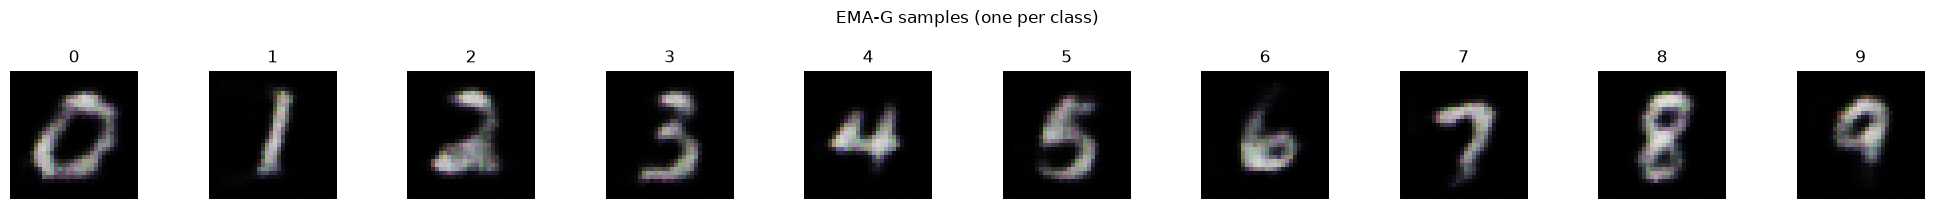

In [13]:
print("\n=== Inference ===")
evaluate(D,     test_imgs, test_lbls, label="D (no SWA)")
evaluate(D_swa, test_imgs, test_lbls, label="D_swa")

# Optional: EMA-G can generate samples for inspection
print("\nGenerating sample images with EMA-G …")
G_ema.eval()
with torch.no_grad():
    z_s  = torch.randn(10, cfg.latent_dim, device=cfg.device)
    y_s  = torch.arange(10, device=cfg.device)
    gen_imgs = G_ema(z_s, y_s).cpu()  # (10, 3, 32, 32)

try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 10, figsize=(20, 2))
    for i, ax in enumerate(axes):
        ax.imshow(gen_imgs[i].permute(1,2,0).numpy(), cmap="gray")
        ax.set_title(str(i)); ax.axis("off")
    plt.suptitle("EMA-G samples (one per class)", y=1.02)
    plt.tight_layout(); plt.show()
except ImportError:
    print("  matplotlib not available; skipping image display")